# Iceberg Playground

In [ ]:
# Install the dependencies for the Iceberg Python client
!pip3 install pyiceberg pyarrow pandas

# Install SQLAlchemy support for PyIceberg
!pip install 'pyiceberg[sql-sqlite]'

In [13]:
# Import the necessary libraries for working with Iceberg tables

from pyiceberg.catalog import load_catalog  # Load the Iceberg catalog
import pyarrow as pa  # For creating and manipulating Arrow tables
import os  # For file system operations
import pandas as pd  # For working with dataframes

In [14]:
# Set up the Iceberg warehouse directory and initialize the SQL catalog

warehouse_path = "./tmp/iceberg-warehouse"  # Local path where Iceberg metadata and data will be stored
os.makedirs(warehouse_path, exist_ok=True)  # Create the directory if it doesn't exist

# Create a local Iceberg catalog using SQLite as the metadata store
catalog = load_catalog(
    "local",  # Catalog name
    **{
        "type": "sql",  # Use SQL (SQLite) for metadata management
        "uri": f"sqlite:///{warehouse_path}/pyiceberg_catalog.db",  # SQLite database location
        "warehouse": f"file://{warehouse_path}",  # File system warehouse location
    },
)

In [15]:
# Create a namespace (database/schema) called "demo" in the Iceberg catalog
# The try-except block prevents errors if the namespace already exists
try:
    catalog.create_namespace("demo")
except Exception:
    # Namespace already exists, so we can safely ignore the error
    pass

In [16]:
# Create a PyArrow Table with sample data containing 3 records

data = pa.table(
    {
        "id": [1, 2, 3],  # ID column with values 1, 2, 3
        "name": ["Alice", "Bob", "Charlie"],  # Name column
        "city": ["Berlin", "Hamburg", "Munich"],  # City column
    }
)

In [17]:
# Create or load an Iceberg table named "demo.people"
# Try to create the table with the schema from the data
# If it already exists, just load it instead (via the except block)

try:
    table = catalog.create_table(
        "demo.people",  # Full table name: namespace.table_name
        schema=data.schema,  # Use the schema from our PyArrow table
    )
except Exception:
    # Table already exists, so we load it instead of creating a new one
    table = catalog.load_table("demo.people")

In [ ]:
# Append the data (3 records) to the Iceberg table
# This writes the data as a new Iceberg data file and creates new metadata

table.overwrite(data)
# table.append(data)

In [25]:
# Scan the entire table and convert the results to a PyArrow Table
# This reads all the data files that are part of the current table snapshot

table.scan().to_arrow()

pyarrow.Table
id: int64
name: string
city: string
----
id: [[1,2,3],[1,2,3],[1,2,3]]
name: [["Alice","Bob","Charlie"],["Shashank","Alice","Bob"],["Shashank","Alice","Bob"]]
city: [["Berlin","Hamburg","Munich"],["Munich","Berlin","Hamburg"],["Munich","Berlin","Hamburg"]]

In [27]:
# Inspect the warehouse structure - find all files created by Iceberg
# This shows the data files, metadata files, and directory structure
!find ./tmp/iceberg-warehouse

./tmp/iceberg-warehouse
./tmp/iceberg-warehouse/demo
./tmp/iceberg-warehouse/demo/people
./tmp/iceberg-warehouse/demo/people/data
./tmp/iceberg-warehouse/demo/people/data/00000-0-b1d20732-0b70-4a79-a17e-809493a96e5c.parquet
./tmp/iceberg-warehouse/demo/people/data/00000-0-f1385e49-7e48-4aef-bfad-8edaa4422d38.parquet
./tmp/iceberg-warehouse/demo/people/data/00000-0-0392af7a-9339-4241-a203-7086849e06cc.parquet
./tmp/iceberg-warehouse/demo/people/data/00000-0-741ce139-f514-4eec-b098-dc3adbd65d4e.parquet
./tmp/iceberg-warehouse/demo/people/metadata
./tmp/iceberg-warehouse/demo/people/metadata/snap-6662002012960057600-0-741ce139-f514-4eec-b098-dc3adbd65d4e.avro
./tmp/iceberg-warehouse/demo/people/metadata/snap-6656967157581408311-0-0392af7a-9339-4241-a203-7086849e06cc.avro
./tmp/iceberg-warehouse/demo/people/metadata/741ce139-f514-4eec-b098-dc3adbd65d4e-m0.avro
./tmp/iceberg-warehouse/demo/people/metadata/snap-451596999583948830-0-b1d20732-0b70-4a79-a17e-809493a96e5c.avro
./tmp/iceberg-ware

In [28]:
# See the metadata files and directory structure created by Iceberg
# This shows file sizes and timestamps for the Iceberg metadata files
!ls -lh ./tmp/iceberg-warehouse/demo.db

ls: ./tmp/iceberg-warehouse/demo.db: No such file or directory


In [29]:
# Scan the table and convert the results to a Pandas DataFrame
# This is useful for displaying the data in a more readable format
table.scan().to_pandas()

,id,name,city
0,1,Alice,Berlin
1,2,Bob,Hamburg
2,3,Charlie,Munich


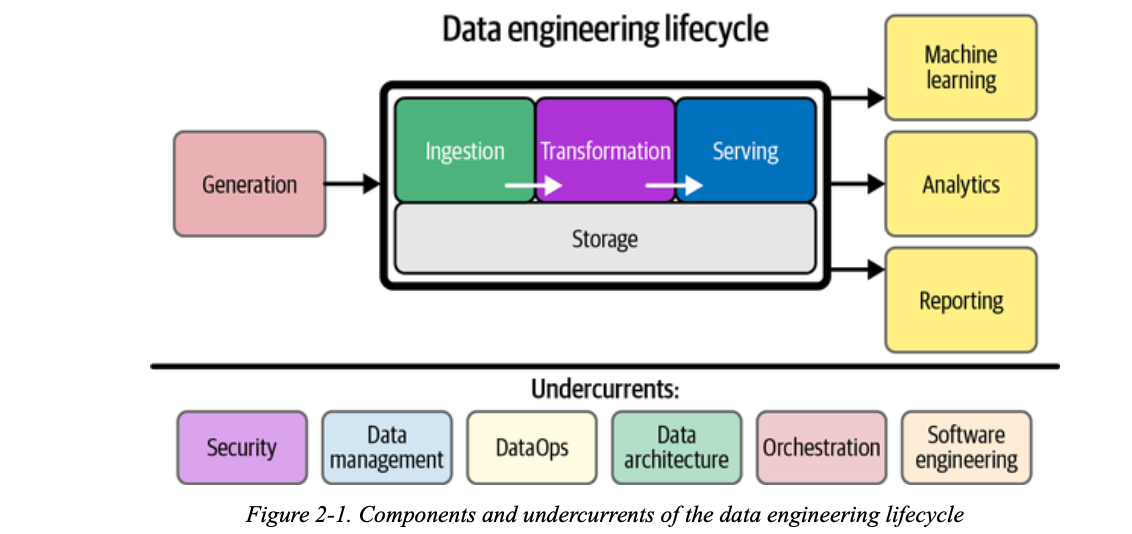


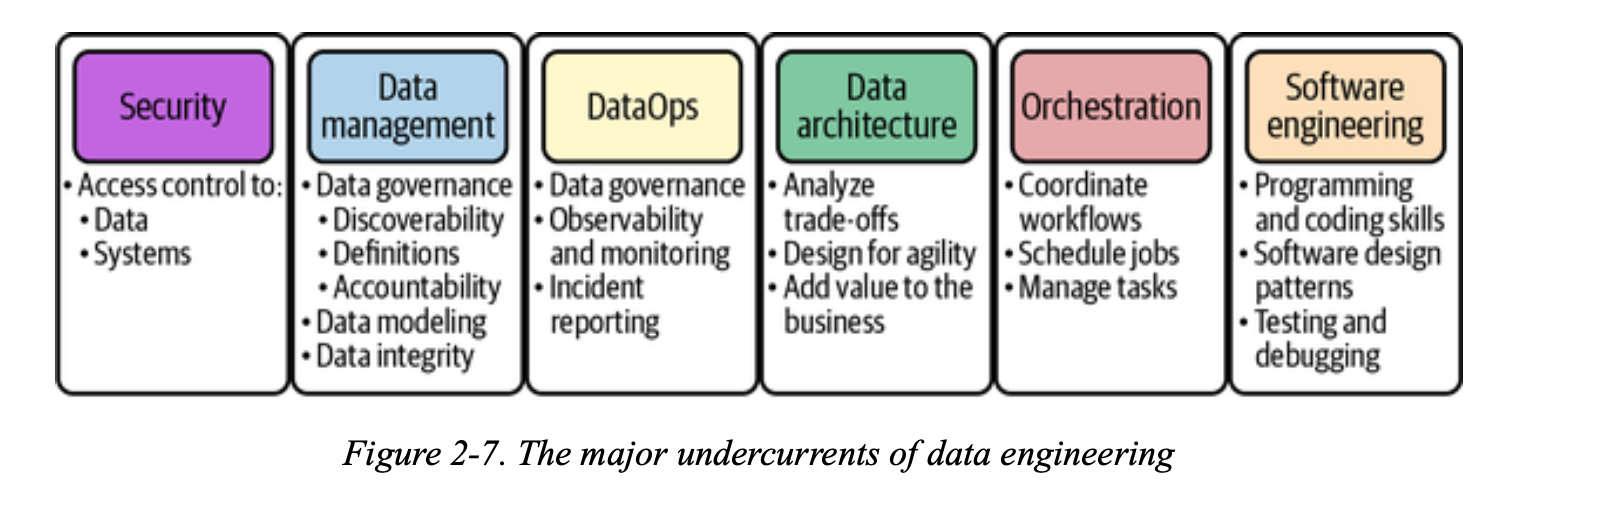
Credit: Fundamentals-of-Data-Engineering-by-Joe-Reis-and-Matt-Housley

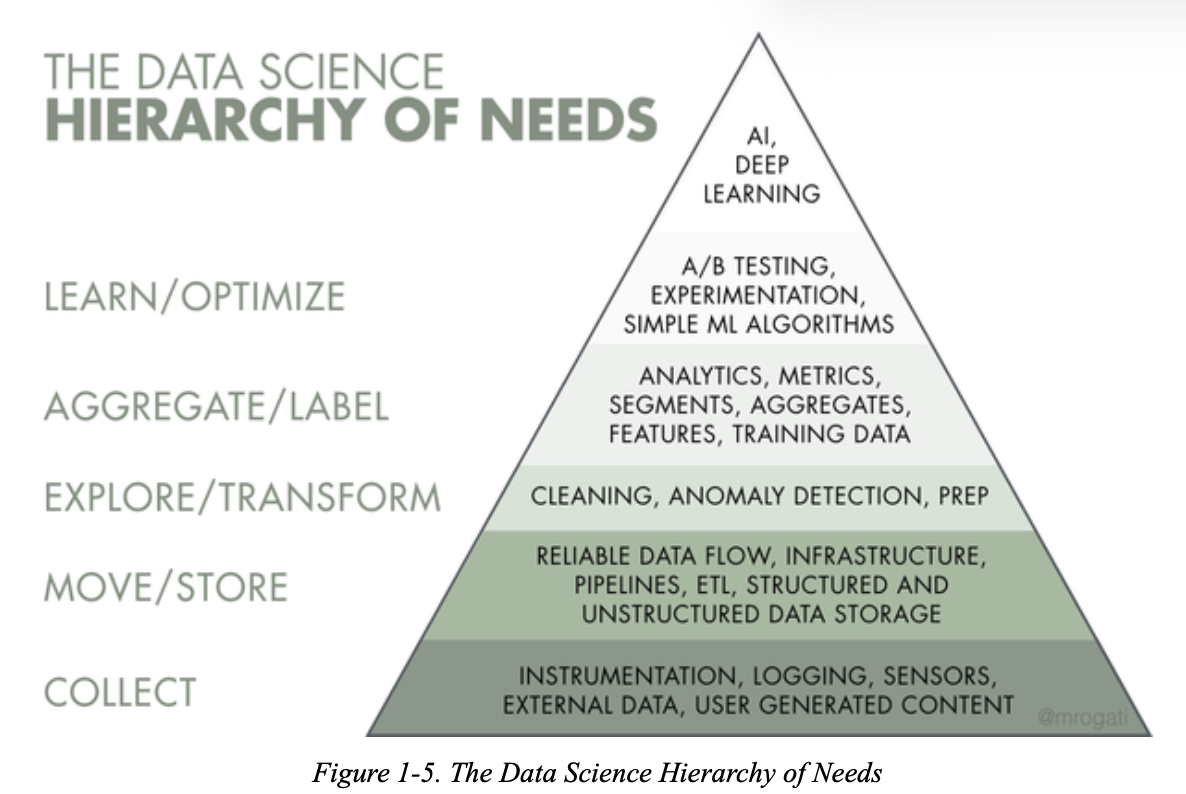
Credit: Fundamentals-of-Data-Engineering-by-Joe-Reis-and-Matt-Housley (Fig. 1,5) 

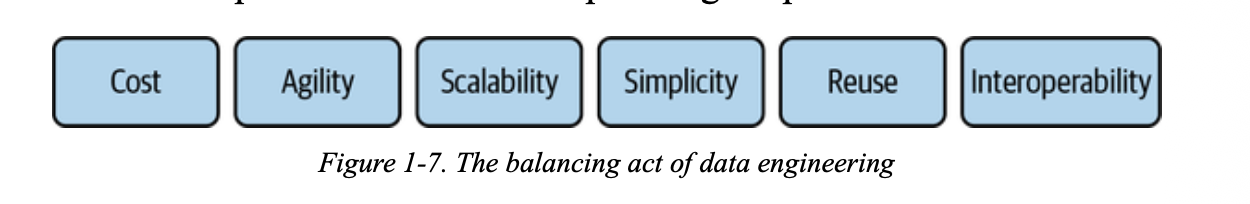
Credit: Fundamentals-of-Data-Engineering-by-Joe-Reis-and-Matt-Housley (Fig. 1,7) 